Fashion-MNIST is a dataset of Zalando's article images—consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.  

In this programming assignment, we will do the following.
- Build a classifier for the Fashion-MNIST dataset that achieves over 85% accuracy on the test set.
- Use only classifiers that are used in the Chapter 3 of the textbook.
- Conduct error analysis following the textbook.

In [ ]:
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

Load the data.

In [ ]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

Reshape the data.

In [ ]:
X_train = X_train.reshape(60000, 28*28)
X_test = X_test.reshape(10000, 28*28)

In [ ]:
X_train.shape, X_test.shape

((60000, 784), (10000, 784))

In [ ]:
y_train.shape, y_test.shape

((60000,), (10000,))

### Labels
Each training and test example is assigned to one of the following labels:

Label	Description
- 0	T-shirt/top
- 1	Trouser
- 2	Pullover
- 3	Dress
- 4	Coat
- 5	Sandal
- 6	Shirt
- 7	Sneaker
- 8	Bag
- 9	Ankle boot

In [ ]:
def plot_item(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = matplotlib.cm.binary, interpolation="nearest")
    plt.axis("off")

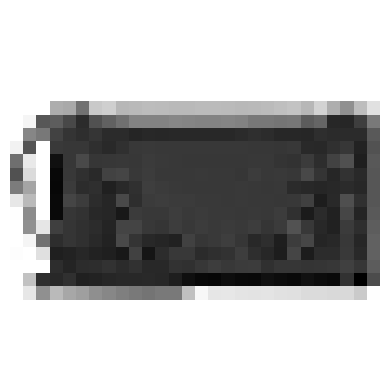

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

some_item = X_train[36001]
some_item_image = some_item.reshape(28, 28)
plt.imshow(some_item_image, cmap = matplotlib.cm.binary, interpolation="nearest")
plt.axis("off");

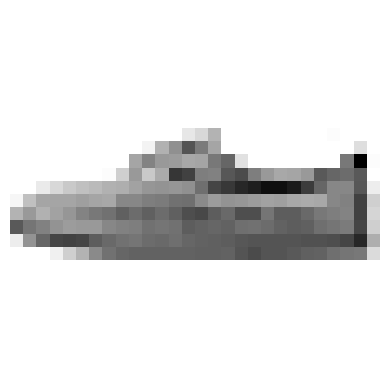

In [ ]:
plot_item(X_train[40000])

In [ ]:
def plot_items(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = matplotlib.cm.binary, **options)
    plt.axis("off")

Plot items from each of all the categories.

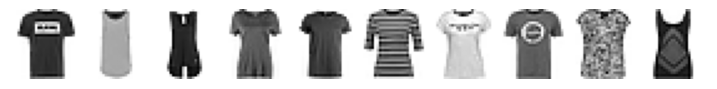

In [ ]:
plt.figure(figsize=(9,9))
X_0 = X_train[(y_train == 0)]
example_images = X_0[:10]
plot_items(example_images, images_per_row=10)

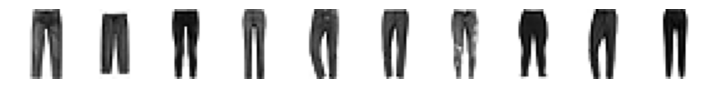

In [ ]:
plt.figure(figsize=(9,9))
X_1 = X_train[(y_train == 1)]
example_images = X_1[:10]
plot_items(example_images, images_per_row=10)

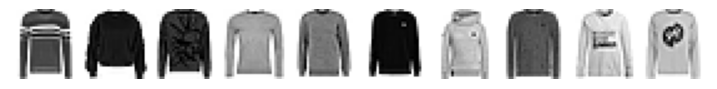

In [ ]:
plt.figure(figsize=(9,9))
X_2 = X_train[(y_train == 2)]
example_images = X_2[:10]
plot_items(example_images, images_per_row=10)

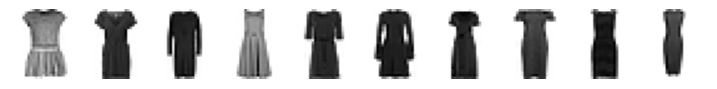

In [ ]:
plt.figure(figsize=(9,9))
X_3 = X_train[(y_train == 3)]
example_images = X_3[:10]
plot_items(example_images, images_per_row=10)

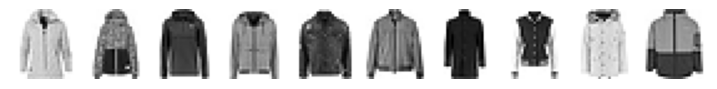

In [ ]:
plt.figure(figsize=(9,9))
X_4 = X_train[(y_train == 4)]
example_images = X_4[:10]
plot_items(example_images, images_per_row=10)

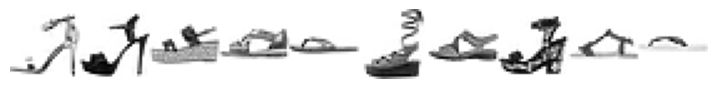

In [ ]:
plt.figure(figsize=(9,9))
X_5 = X_train[(y_train == 5)]
example_images = X_5[:10]
plot_items(example_images, images_per_row=10)

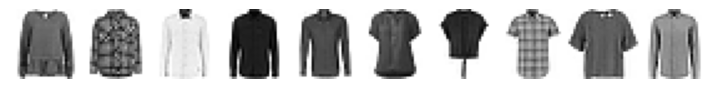

In [ ]:
plt.figure(figsize=(9,9))
X_6 = X_train[(y_train == 6)]
example_images = X_6[:10]
plot_items(example_images, images_per_row=10)

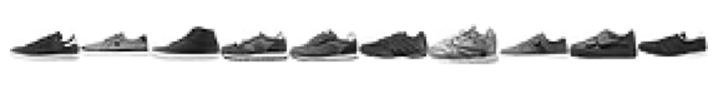

In [ ]:
plt.figure(figsize=(9,9))
X_7 = X_train[(y_train == 7)]
example_images = X_7[:10]
plot_items(example_images, images_per_row=10)

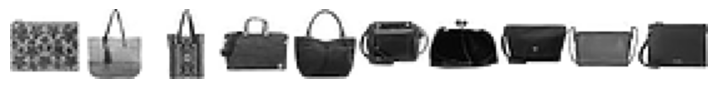

In [ ]:
plt.figure(figsize=(9,9))
X_8 = X_train[(y_train == 8)]
example_images = X_8[:10]
plot_items(example_images, images_per_row=10)

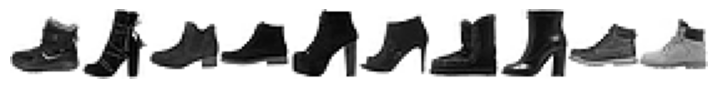

In [ ]:
plt.figure(figsize=(9,9))
X_9 = X_train[(y_train == 9)]
example_images = X_9[:10]
plot_items(example_images, images_per_row=10)

### Binary classifier (shirt or not shirt)

Write code to create y labels for a binary classifier to distinguish shirt or not-shirt. (10 points)



In [ ]:
# fill in code



In [ ]:
y_train_shirt.shape

(60000,)

In [ ]:
y_test_shirt.shape

(10000,)

Train a binary classifier using SGDClassifier. (10 points)

Use max_iter=1000, tol=1e-3, random_state=42.

In [ ]:
from sklearn.linear_model import SGDClassifier

#fill in code



SGDClassifier(random_state=42)

Predict whether some_item is a shirt. (5 points)

In [ ]:
# fill in code


array([False])

Follow the text to obtain the accuracy using cross validation. (10 points)

In [ ]:
from sklearn.model_selection import cross_val_score
# fill in code


array([0.88805, 0.794  , 0.91905])



Use cross validtion to conduct predictions on the training set. (10 points)



In [ ]:
from sklearn.model_selection import cross_val_predict
# fill in code


Obtain the confusion matrix. (10 points)

In [ ]:
from sklearn.metrics import confusion_matrix
# fill in code


array([[47957,  6043],
       [ 1935,  4065]])

####Calculate precision, recall and F1 score by passing in the ground truth and the prediction.

Calculate precision. (5 points)

In [ ]:
from sklearn.metrics import precision_score, recall_score
# fill in code


0.40215670755836963

Calculate recall. (5 points)

In [ ]:
# fill in code


0.6775

Calculate F1 score. (5 points)

In [ ]:
from sklearn.metrics import f1_score
# fill in code


0.504718152470822

Get decision scores.

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_shirt, cv=3,
                             method="decision_function")

Compute precision and recall for all posssible threshold.

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_shirt, y_scores)

## Impact of threshold

Follow the text to plot the precision and recall versus the decision threshold. (5 points)

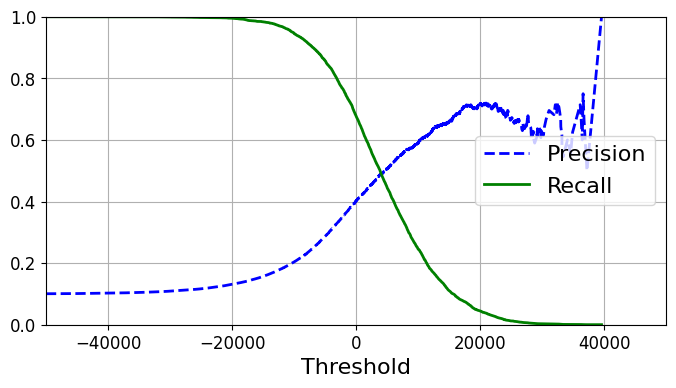

In [ ]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16) # Not shown in the book
    plt.xlabel("Threshold", fontsize=16)        # Not shown
    plt.grid(True)                              # Not shown
    plt.axis([-50000, 50000, 0, 1])             # Not shown

plt.figure(figsize=(8, 4))                      # Not shown
# fill in code
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

## Precision and Recall Curve

Plot the precsion versus recall. (5 points)

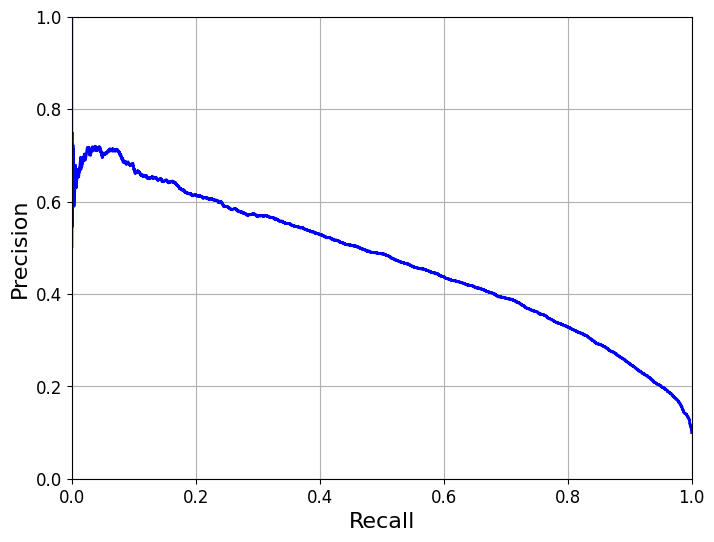

In [ ]:
def plot_precision_vs_recall(precisions, recalls):
    plt.plot(recalls, precisions, "b-", linewidth=2)
    plt.xlabel("Recall", fontsize=16)
    plt.ylabel("Precision", fontsize=16)
    plt.axis([0, 1, 0, 1])
    plt.grid(True)

plt.figure(figsize=(8, 6))
# fill in code
plot_precision_vs_recall(precisions, recalls)
plt.show()

## ROC curve

Plot the ROC curve. (5 points)

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_shirt, y_scores)

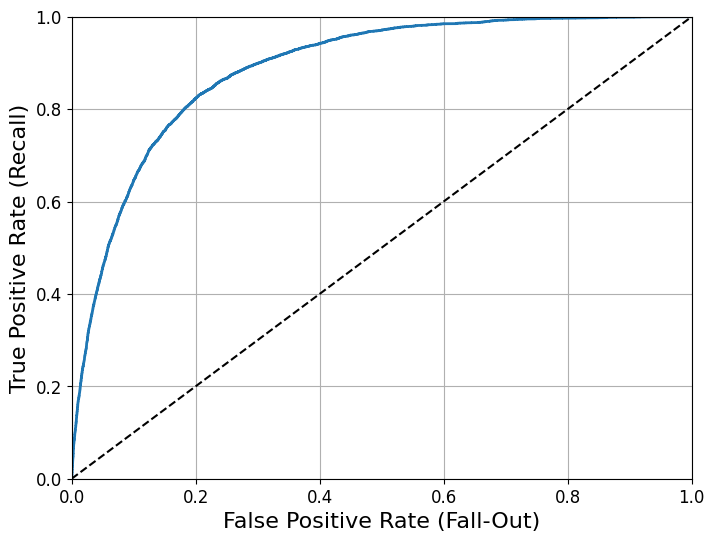

In [ ]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
    plt.axis([0, 1, 0, 1])                                    # Not shown in the book
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16) # Not shown
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)    # Not shown
    plt.grid(True)                                            # Not shown

plt.figure(figsize=(8, 6))                         # Not shown
# fill in code
plot_roc_curve(fpr, tpr)
plt.show()

Calculate ROC AUC score.

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_shirt, y_scores)

np.float64(0.8873327407407408)

### Random Forest Binary Classifier

Train a random forest classifer.

Plot the ROC curves for SDD classifier and the random forest classifer.

Calculate the roc_auc_score for the random forest classifier.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_shirt, cv=3,
                                    method="predict_proba")

In [ ]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_shirt,y_scores_forest)

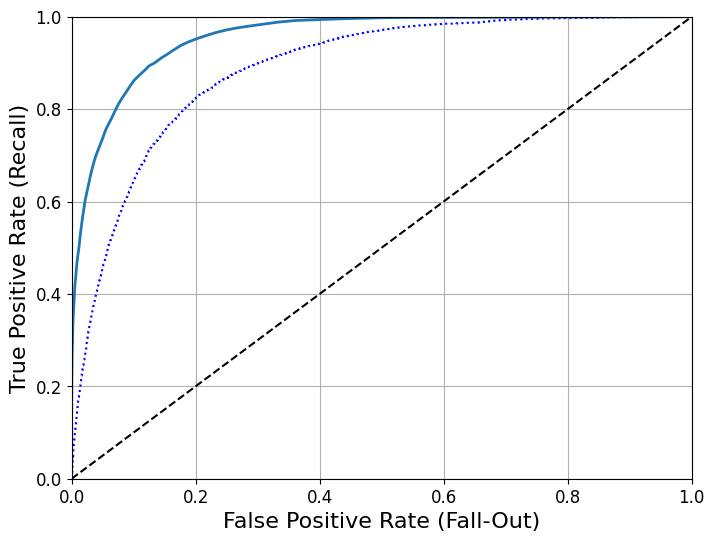

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.show()

In [ ]:
roc_auc_score(y_train_shirt, y_scores_forest)

np.float64(0.956154913580247)

Note the random forest classifier has better ROC AUC score.

### Multiclass Classification

Use SGD classifer for multiclass classification and conduct error analysis. Explore misclassifications between T-shirts and shirts.

Find a better classifier and make sure the accuracy is above 85% using trainning data and test the classifer on the test data.

First, we scale the data.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

In [ ]:
from sklearn.linear_model import SGDClassifier

# fill in code use tol=1e-3, random_state=42

# only use the first 1000 training sample to save time
sgd_clf.fit(X_train_scaled[:1000], y_train[:1000])
sgd_clf.predict([some_item])

array([8], dtype=uint8)

In [ ]:
print(y_train[36001])

8


Make predictions and obtain confustion matrix.

In [ ]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[4777,   19,   88,  448,   26,    1,  550,    0,   91,    0],
       [  14, 5685,   38,  199,   15,    1,   45,    0,    3,    0],
       [  42,    5, 4367,   90,  772,    0,  663,    0,   61,    0],
       [ 212,  105,   76, 5205,  191,    0,  199,    0,   12,    0],
       [   8,    5,  617,  330, 4449,    0,  568,    0,   23,    0],
       [   4,    2,    3,   11,    2, 5489,   18,  277,   72,  122],
       [ 806,   18,  635,  372,  550,    0, 3441,    1,  176,    1],
       [   0,    0,    0,    0,    0,  319,    0, 5422,   16,  243],
       [  31,    3,   28,  121,   33,   11,  138,   35, 5595,    5],
       [   0,    0,    0,    6,    1,  100,    7,  251,    4, 5631]])

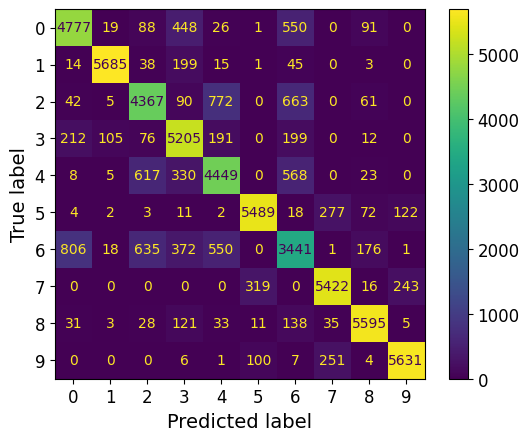

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

#y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

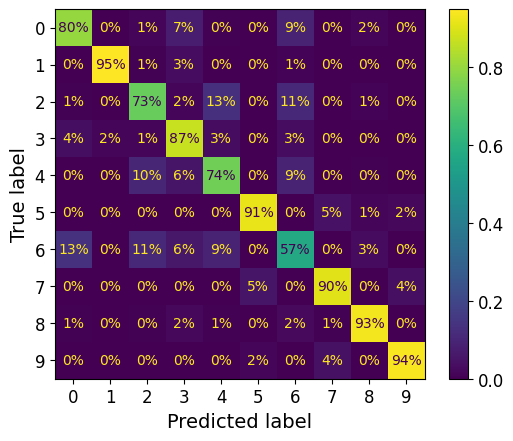

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.show()

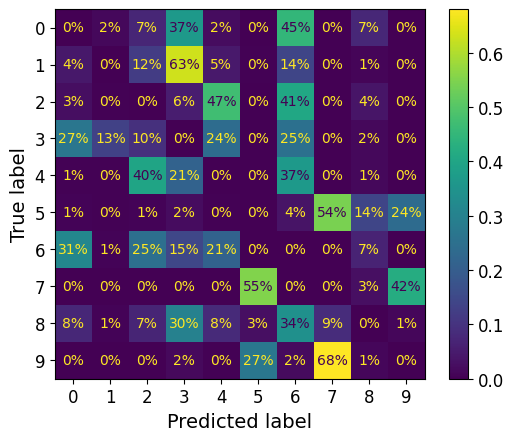

In [ ]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

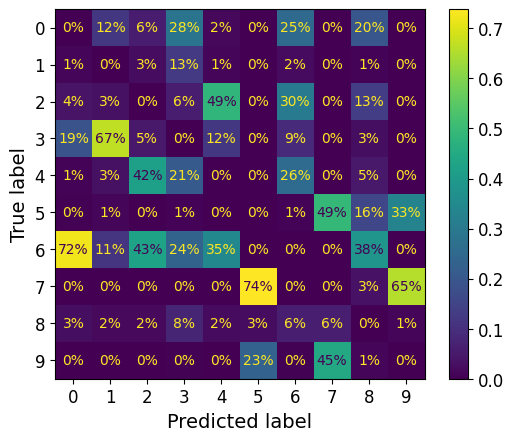

In [ ]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
plt.show()

Explore misclassifications between T-shirts and shirts. (5 points)

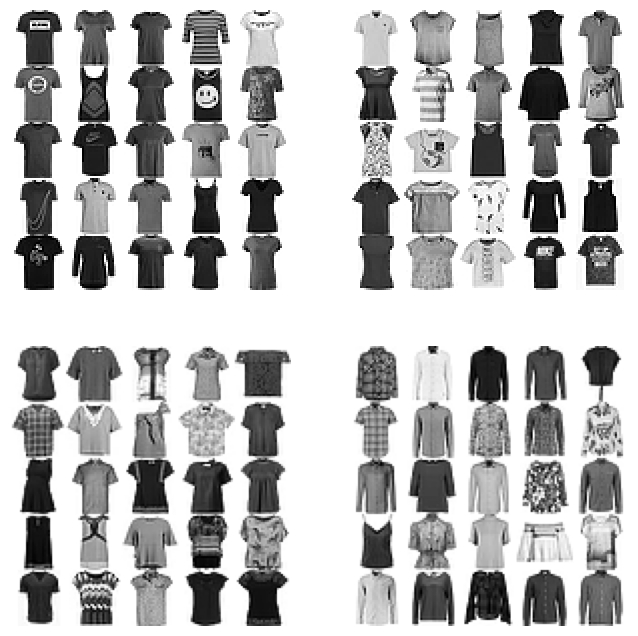

In [ ]:
# fill in code
cl_a, cl_b =
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

plt.figure(figsize=(8,8))
plt.subplot(221); plot_items(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_items(X_ab[:25], images_per_row=5)
plt.subplot(223); plot_items(X_ba[:25], images_per_row=5)
plt.subplot(224); plot_items(X_bb[:25], images_per_row=5)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(forest_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8776, 0.8825, 0.8805])

In [ ]:
forest_clf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

Apply scale transform on X_test and make predictions on the test set. (10 points)

In [ ]:
# fill in code
X_test_scaled =
y_predict_test =

Calculate the test accuracy.

In [ ]:
accuarcy =  np.sum(y_predict_test == y_test) / len(y_test)
print(accuarcy)

0.8764


Indeed, we beat 85% of accuracy.